## Ultrachat finetune eval: mean log-likelihood plot

Loads per-sample results from `results/finetune_eval_samples` (Ultrachat runs only), applies run filters, and plots **mean log-likelihood** of the correct choice (or **mean NLL** if you set `use_mean_nll=True`) — one subplot per task (arc_easy on x-axis vs each task on y-axis).

Uses **Theil-Sen robust regression** (outlier-resistant) with optional confidence bands and slope/R² annotations.

**Config (edit in the next cell):**
- `EVAL_VERSION` — `"v2"`, `"v3"`, `"v2v3"`, or `"ar_v2_diff_v3"` (AR from v2, diffusion from v3).
- `X_TASK` — x-axis task: `"val_loss"` (from val_nll) or any test task like `"arc_easy"`.
- `Y_TASKS` — list of y-axis tasks, or `None` for all available minus x_task. E.g. `["hellaswag", "piqa"]`.
- `OUTLIER_STD` — drop outlier rows > N std from per-run mean (0 = no filtering).
- `FIT_QUANTILE_CLIP` — fraction of extreme x-values to exclude from regression fit per run (0-0.5, e.g. 0.1 trims 10th/90th percentile). Points still shown.
- `SHOW_CONFIDENCE` / `SHOW_STATS` — Theil-Sen confidence bands / slope+R² annotations.
- `use_mean_nll` — if `True`, plot mean NLL (= −mean log-lik).

All logic lives in `analyze/ultrachat_finetune_plot.py`.  
CLI: `python -m analyze.ultrachat_finetune_plot --ar-v2-diff-v3 --x-task arc_easy --fit-clip 0.1`

Processed 59/595 sample files...
Processed 118/595 sample files...
Processed 177/595 sample files...
Processed 236/595 sample files...
Processed 295/595 sample files...
Processed 354/595 sample files...
Processed 413/595 sample files...
Processed 472/595 sample files...
Processed 531/595 sample files...
Processed 590/595 sample files...
Processed 595/595 sample files...
Aggregated 595 files in 2.3s.
Checkpoints per run (after filters, before outlier drop):
  bd3lm/pythia-2.8b-bd3lm-bs1-ultrachat200k-v3: 20
  bd3lm/pythia-2.8b-bd3lm-bs8-ultrachat200k-v3: 20
  mamba/mamba-2.8b-ultrachat200k-v2: 11
  mdlm/pythia-2.8b-mdlm-ultrachat200k-v3: 20
  pythia/pythia-2.8b-ultrachat200k-v2: 11
Dropped 1 outlier rows (>3.0 std from run mean)
Checkpoints per run (after outlier drop):
  bd3lm/pythia-2.8b-bd3lm-bs1-ultrachat200k-v3: 20
  bd3lm/pythia-2.8b-bd3lm-bs8-ultrachat200k-v3: 20
  mamba/mamba-2.8b-ultrachat200k-v2: 11
  mdlm/pythia-2.8b-mdlm-ultrachat200k-v3: 19
  pythia/pythia-2.8b-ultrachat200

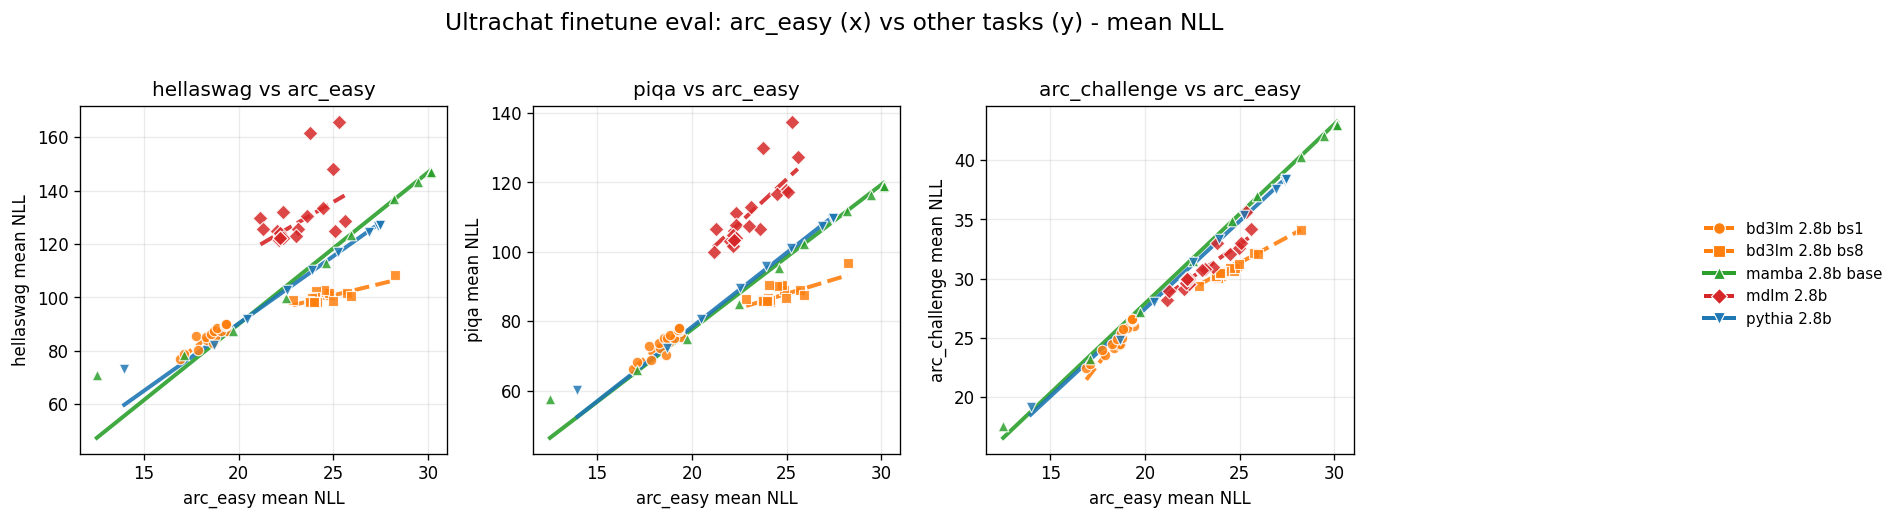

In [2]:
# --- Config ---
EVAL_VERSION = "ar_v2_diff_v3"  # "v2", "v3", "v2v3", or "ar_v2_diff_v3" (AR from v2, diffusion from v3)
X_TASK = "arc_easy"     # x-axis: "val_loss" (from val_nll) or any test task like "arc_easy"
Y_TASKS = ["hellaswag", "piqa", "arc_challenge"]          # y-axis subset, e.g. ["hellaswag", "piqa", "arc_challenge"]; None = all minus x
OUTLIER_STD = 3.0       # drop outlier rows > N std from per-run mean (0 = off)
FIT_QUANTILE_CLIP = 0.1 # trim top/bottom Q fraction of x from regression fit per run (0 = use all)
use_mean_nll = True     # True => plot mean NLL instead of mean log-likelihood
SHOW_CONFIDENCE = False # Theil-Sen confidence bands
SHOW_STATS = False      # slope/R² annotations
MAX_SAMPLE_WORKERS = None

# --- Setup ---
import os, sys
from pathlib import Path

REPO_ROOT = Path("/fast/pmayilvahanan/Interplay-LM-Reasoning")
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

from analyze.ultrachat_finetune_plot import (
    load_and_plot_mean_loglik,
    RUN_NAME_REGEX_V2, RUN_NAME_REGEX_V3, RUN_NAME_REGEX_V2_OR_V3,
    DROP_BASE_FOR_DIFFUSION_PATTERNS, VERSION_AR_V2_DIFF_V3,
)

_version_map = {"v2": RUN_NAME_REGEX_V2, "v3": RUN_NAME_REGEX_V3, "v2v3": RUN_NAME_REGEX_V2_OR_V3}
if EVAL_VERSION == "ar_v2_diff_v3":
    run_name_regex = None
    version_by_model_type = VERSION_AR_V2_DIFF_V3
else:
    run_name_regex = _version_map.get(EVAL_VERSION, RUN_NAME_REGEX_V2)
    version_by_model_type = None

df, fig = load_and_plot_mean_loglik(
    run_name_regex=run_name_regex,
    version_by_model_type=version_by_model_type,
    excluded_run_patterns=[],
    drop_base_for_run_patterns=DROP_BASE_FOR_DIFFUSION_PATTERNS,
    use_mean_nll=use_mean_nll,
    x_task=X_TASK,
    y_tasks=Y_TASKS,
    outlier_std=OUTLIER_STD,
    fit_quantile_clip=FIT_QUANTILE_CLIP,
    max_workers=MAX_SAMPLE_WORKERS,
    show=True,
    show_confidence=SHOW_CONFIDENCE,
    show_stats=SHOW_STATS,
)